In [ ]:
# ==========================================================
# CREDIT CARD FRAUD DETECTION
# Step 1 : Import Required Libraries
# ==========================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Save Model
import joblib
import os



In [ ]:
df = pd.read_csv("creditcard.csv")

print("Dataset Loaded Successfully ")

Dataset Loaded Successfully 


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df.shape

(284807, 31)

In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
df.size

8829017

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 1081


In [ ]:
df = df.drop_duplicates()

print("Duplicate Rows After Removal :", df.duplicated().sum())

Duplicate Rows After Removal : 0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,283726.0,94811.077600,47481.047891,0.000000,54204.750000,84692.500000,139298.000000,172792.000000
V1,283726.0,0.005917,1.948026,-56.407510,-0.915951,0.020384,1.316068,2.454930
V2,283726.0,-0.004135,1.646703,-72.715728,-0.600321,0.063949,0.800283,22.057729
V3,283726.0,0.001613,1.508682,-48.325589,-0.889682,0.179963,1.026960,9.382558
V4,283726.0,-0.002966,1.414184,-5.683171,-0.850134,-0.022248,0.739647,16.875344
V5,283726.0,0.001828,1.377008,-113.743307,-0.689830,-0.053468,0.612218,34.801666
V6,283726.0,-0.001139,1.331931,-26.160506,-0.769031,-0.275168,0.396792,73.301626
V7,283726.0,0.001801,1.227664,-43.557242,-0.552509,0.040859,0.570474,120.589494
V8,283726.0,-0.000854,1.179054,-73.216718,-0.208828,0.021898,0.325704,20.007208
V9,283726.0,-0.001596,1.095492,-13.434066,-0.644221,-0.052596,0.595977,15.594995


In [ ]:
print(df["Class"].value_counts())

Class
0    283253
1       473
Name: count, dtype: int64


In [ ]:
print(df["Class"].value_counts(normalize=True) * 100)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


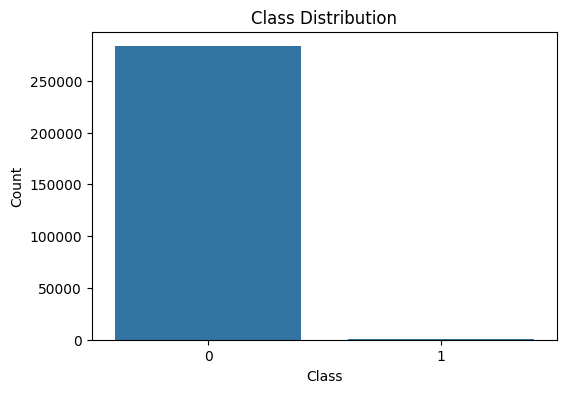

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x="Class", data=df)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [ ]:
fraud = df[df["Class"] == 1]

genuine = df[df["Class"] == 0]

print("Fraud Transactions :", fraud.shape[0])
print("Genuine Transactions :", genuine.shape[0])

Fraud Transactions : 473
Genuine Transactions : 283253


In [ ]:
df["Amount"].describe()

,Amount
count,3940.000000
mean,65.338447
std,214.494564
min,0.000000
25%,2.237500
50%,12.990000
75%,55.337500
max,7712.430000


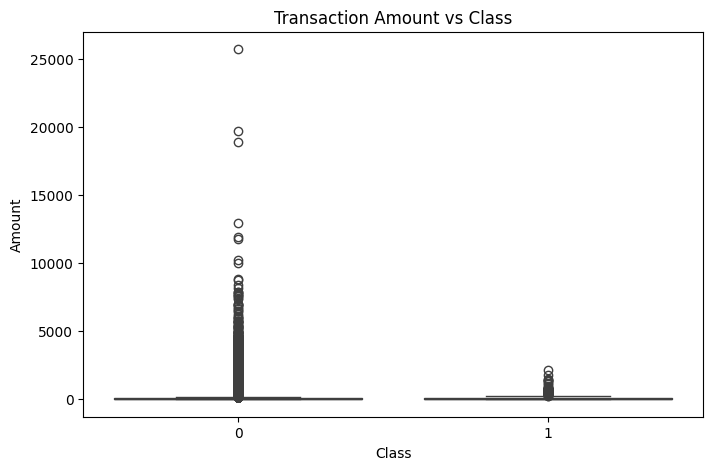

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Class", y="Amount", data=df)

plt.title("Transaction Amount vs Class")

plt.show()

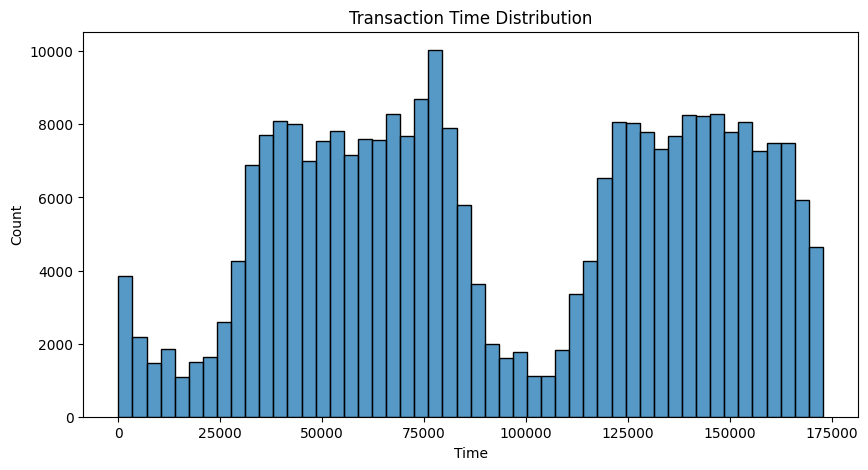

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df["Time"], bins=50)

plt.title("Transaction Time Distribution")

plt.show()

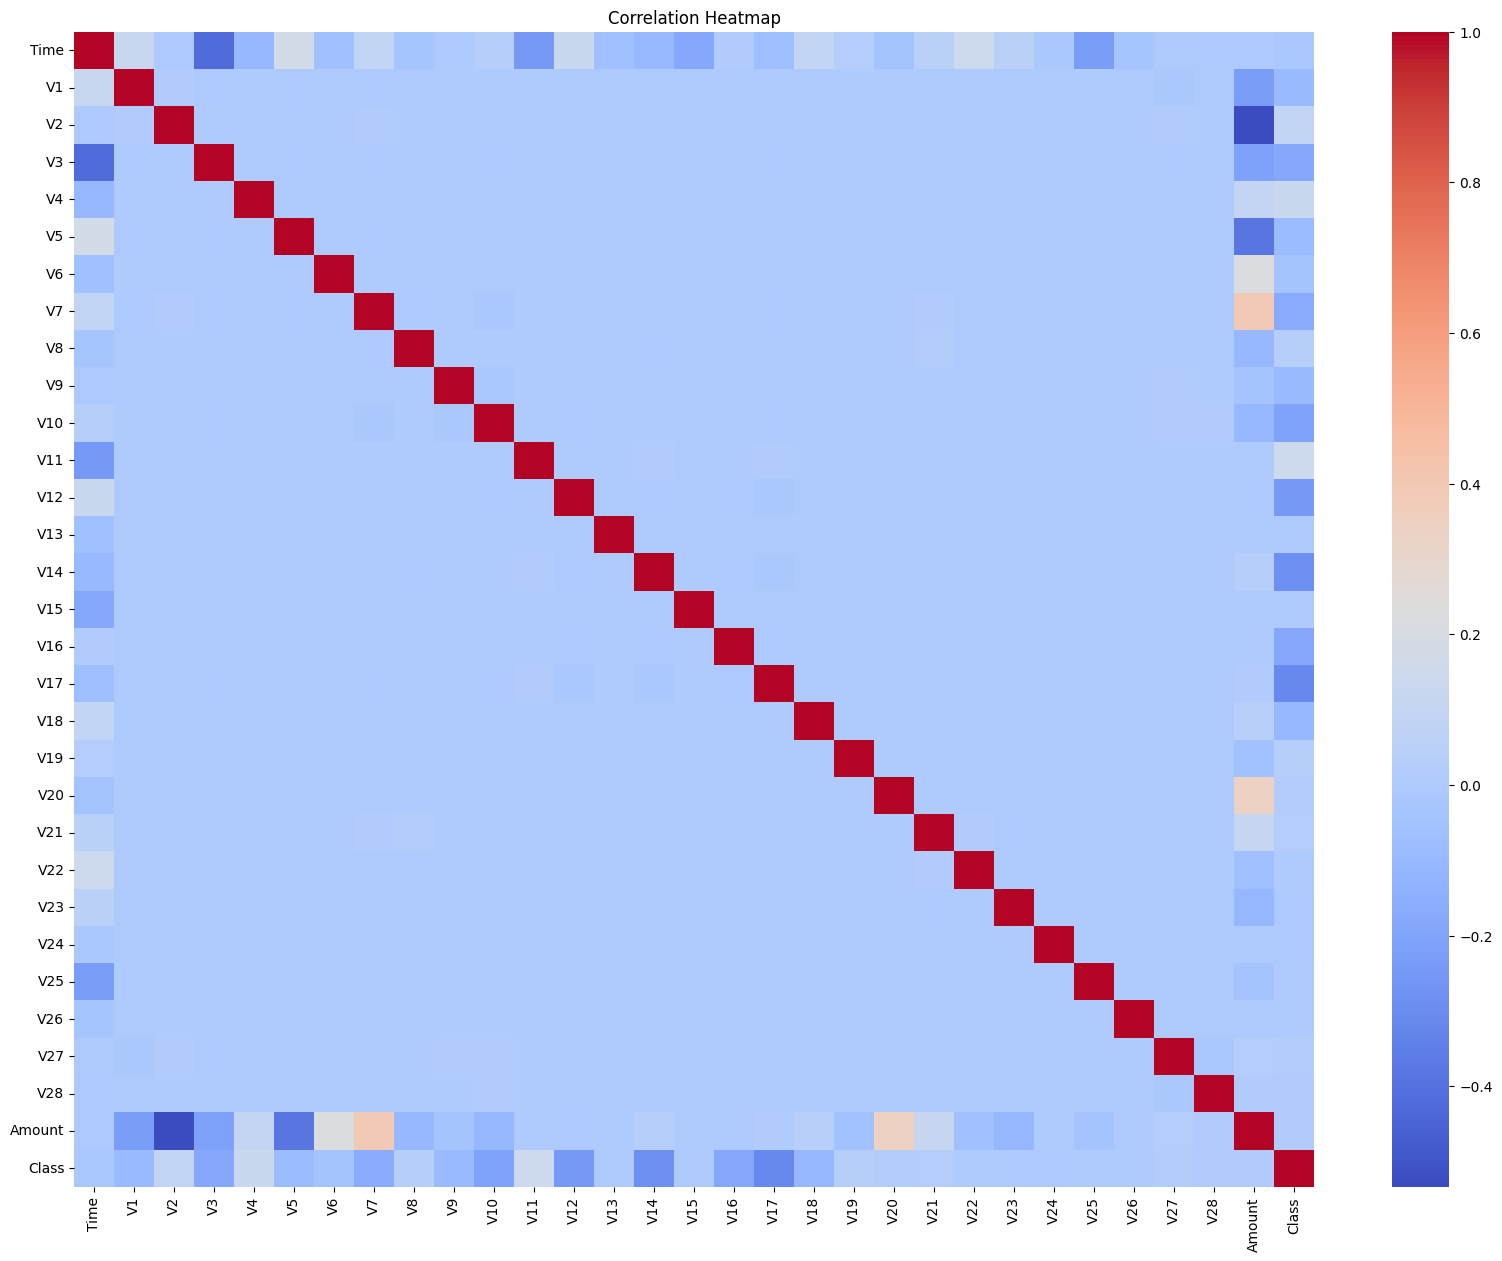

In [ ]:
plt.figure(figsize=(20,15))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# Features
X = df.drop("Class", axis=1)

# Target
y = df["Class"]

In [ ]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (283726, 30)
Shape of y: (283726,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X["Time"] = scaler.fit_transform(X[["Time"]])

X["Amount"] = scaler.fit_transform(X[["Amount"]])

In [ ]:
X.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.612150,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.392981
1,-1.612150,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.292112
2,-1.611167,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.460929
3,-1.611167,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.271191
4,-1.610183,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.021689


In [ ]:
y.value_counts()

,count
Class,
0,283253
1,473


In [ ]:
df = df.dropna(subset=["Class"])

In [ ]:
print(df["Class"].isnull().sum())

0


In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [ ]:
print(X.shape)
print(y.shape)
print(y.value_counts())

(283726, 30)
(283726,)
Class
0    283253
1       473
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(df.shape)
df.head()

(283726, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


LOGISTIC REGRESION

In [ ]:
# ==========================================
# Logistic Regression Model
# ==========================================

logistic_model = LogisticRegression(random_state=42)

# Train the model
logistic_model.fit(X_train, y_train)

# Predictions
y_pred_lr = logistic_model.predict(X_test)

# Probability Predictions (needed for ROC-AUC)
y_prob_lr = logistic_model.predict_proba(X_test)[:,1]

print("Logistic Regression Model Trained Successfully ✅")

Logistic Regression Model Trained Successfully ✅


In [ ]:
y_pred = logistic_model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_pred))

Accuracy : 0.9989602791386177
Precision: 0.7
Recall   : 0.6631578947368421
F1 Score : 0.6810810810810811
ROC AUC  : 0.8313406461910366


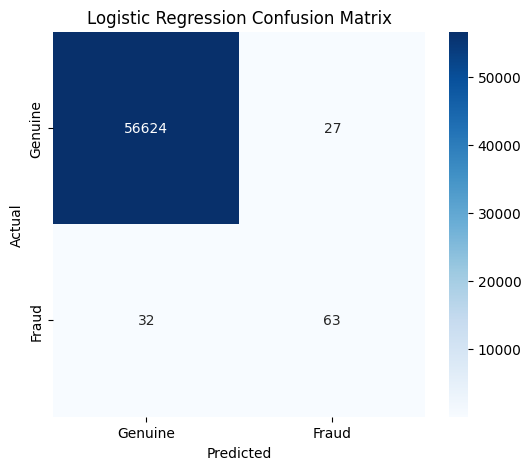

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.70      0.66      0.68        95

    accuracy                           1.00     56746
   macro avg       0.85      0.83      0.84     56746
weighted avg       1.00      1.00      1.00     56746



decision tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

decisiotree = DecisionTreeClassifier(criterion="gini",
    random_state=42
)

In [ ]:
decisiotree.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_preddt= decisiotree.predict(X_test)

In [ ]:
from sklearn.metrics import precision_score,recall_score , f1_score,accuracy_score,confusion_matrix,roc_auc_score

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_preddt))
print("Precision:", precision_score(y_test, y_preddt))
print("Recall   :", recall_score(y_test, y_preddt))
print("F1 Score :", f1_score(y_test, y_preddt))
print("ROC AUC  :", roc_auc_score(y_test, y_preddt))

Accuracy : 0.999048391076023
Precision: 0.7204301075268817
Recall   : 0.7052631578947368
F1 Score : 0.7127659574468085
ROC AUC  : 0.8524021037395169


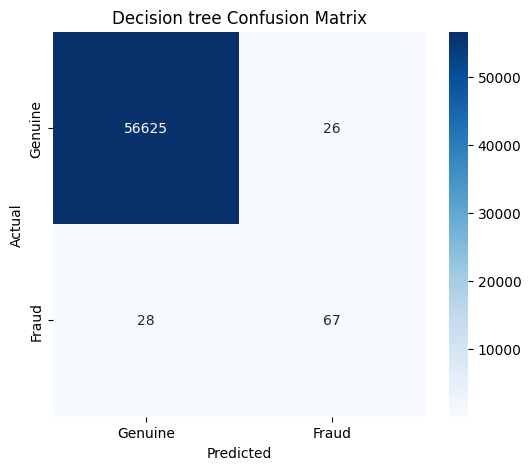

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_preddt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision tree Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(y_test, y_preddt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.72      0.71      0.71        95

    accuracy                           1.00     56746
   macro avg       0.86      0.85      0.86     56746
weighted avg       1.00      1.00      1.00     56746



RANDOM FOREST CLASSIFIER

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = random_forest.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_rf))

Accuracy : 0.9995065731505305
Precision: 0.971830985915493
Recall   : 0.7263157894736842
F1 Score : 0.8313253012048193
ROC AUC  : 0.8631402427977767


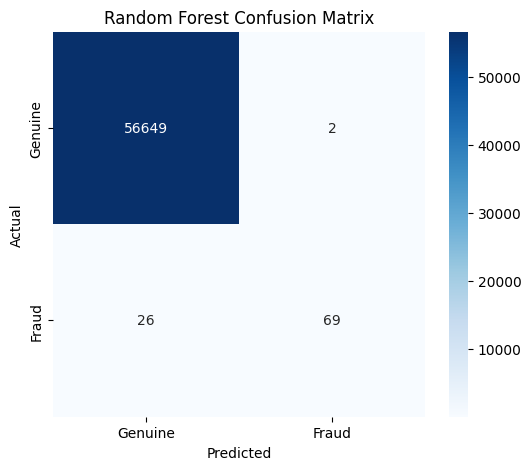

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        0.9989602791386177,
        0.9989779015260988,
        0.9995065731505305
    ],
    "Precision": [
        0.7000000000000000,
        0.6907216494845361,
        0.9718309859154930
    ],
    "Recall": [
        0.6631578947368421,
        0.7052631578947368,
        0.7263157894736842
    ],
    "F1 Score": [
        0.6810810810810811,
        0.6979166666666666,
        0.8313253012048193
    ],
    "ROC AUC": [
        0.8313406461910366,
        0.8523667998613857,
        0.8631402427977767
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.998960,0.700000,0.663158,0.681081,0.831341
1,Decision Tree,0.998978,0.690722,0.705263,0.697917,0.852367
2,Random Forest,0.999507,0.971831,0.726316,0.831325,0.863140


In [ ]:
comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9990,0.7000,0.6632,0.6811,0.8313
1,Decision Tree,0.9990,0.6907,0.7053,0.6979,0.8524
2,Random Forest,0.9995,0.9718,0.7263,0.8313,0.8631


In [ ]:
import os
import joblib

# Create folder to store models
os.makedirs("saved_models", exist_ok=True)

# Save the trained Random Forest model
joblib.dump(random_forest, "saved_models/best_model.pkl")

# Save the scaler
joblib.dump(scaler, "saved_models/scaler.pkl")

print("✅ Model and Scaler saved successfully!")

✅ Model and Scaler saved successfully!


In [ ]:
time_scaler = StandardScaler()
amount_scaler = StandardScaler()

X["Time"] = time_scaler.fit_transform(X[["Time"]])
X["Amount"] = amount_scaler.fit_transform(X[["Amount"]])

In [ ]:
joblib.dump(time_scaler, "saved_models/time_scaler.pkl")
joblib.dump(amount_scaler, "saved_models/amount_scaler.pkl")